In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# ***EDA***

In [5]:
df.shape

(32581, 12)

In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


### Check Missing Values

In [10]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [11]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': df.isnull().mean() * 100
})

missing.sort_values(by='Missing_Percentage', ascending=False)

,Missing_Count,Missing_Percentage
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000
person_income,0,0.000000
person_age,0,0.000000
person_home_ownership,0,0.000000
loan_intent,0,0.000000
loan_grade,0,0.000000
loan_amnt,0,0.000000
loan_status,0,0.000000
loan_percent_income,0,0.000000


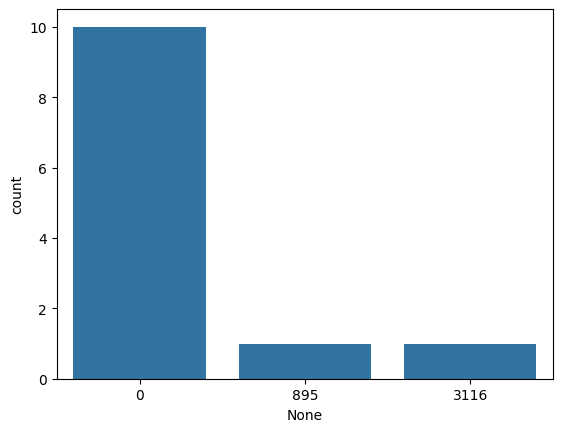

In [14]:
sns.countplot(x=df.isnull().sum())
plt.show()

## **Check Duplicate Rows**

In [61]:
df.duplicated().sum()

np.int64(165)

In [62]:
df[df.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4,<=25
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3,<=25
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4,<=25
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3,<=25
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4,<=25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12,36-45
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17,36-45
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12,46-55
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16,36-45


**Examine Categorical and Numerical Columns**

In [63]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [64]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [65]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

In [66]:
for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(df[col].describe())


--- person_age ---
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

--- person_income ---
count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

--- person_emp_length ---
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

--- loan_amnt ---
count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

--- loan_int_rate ---
count    29465.000000
mean        11.011695

**Target Variable Analysis**

In [67]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


In [68]:
df['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.183604
1,21.816396


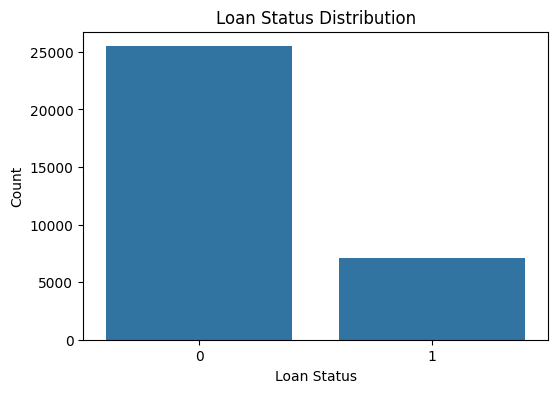

In [69]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='loan_status')

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [70]:
target_percentage = (
    df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
)

target_percentage

,proportion
loan_status,
0,78.183604
1,21.816396


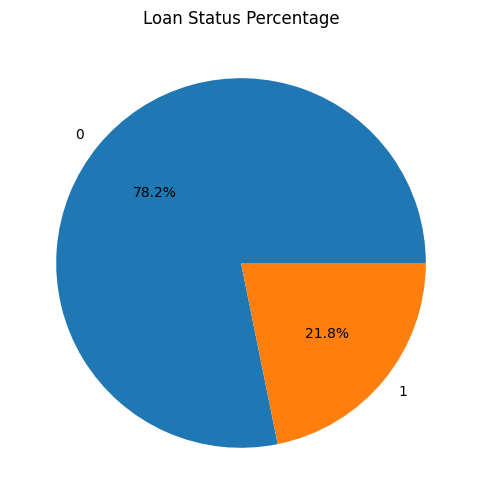

In [71]:
plt.figure(figsize=(6, 6))

df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Loan Status Percentage")
plt.ylabel("")

plt.show()

**Numerical Features**

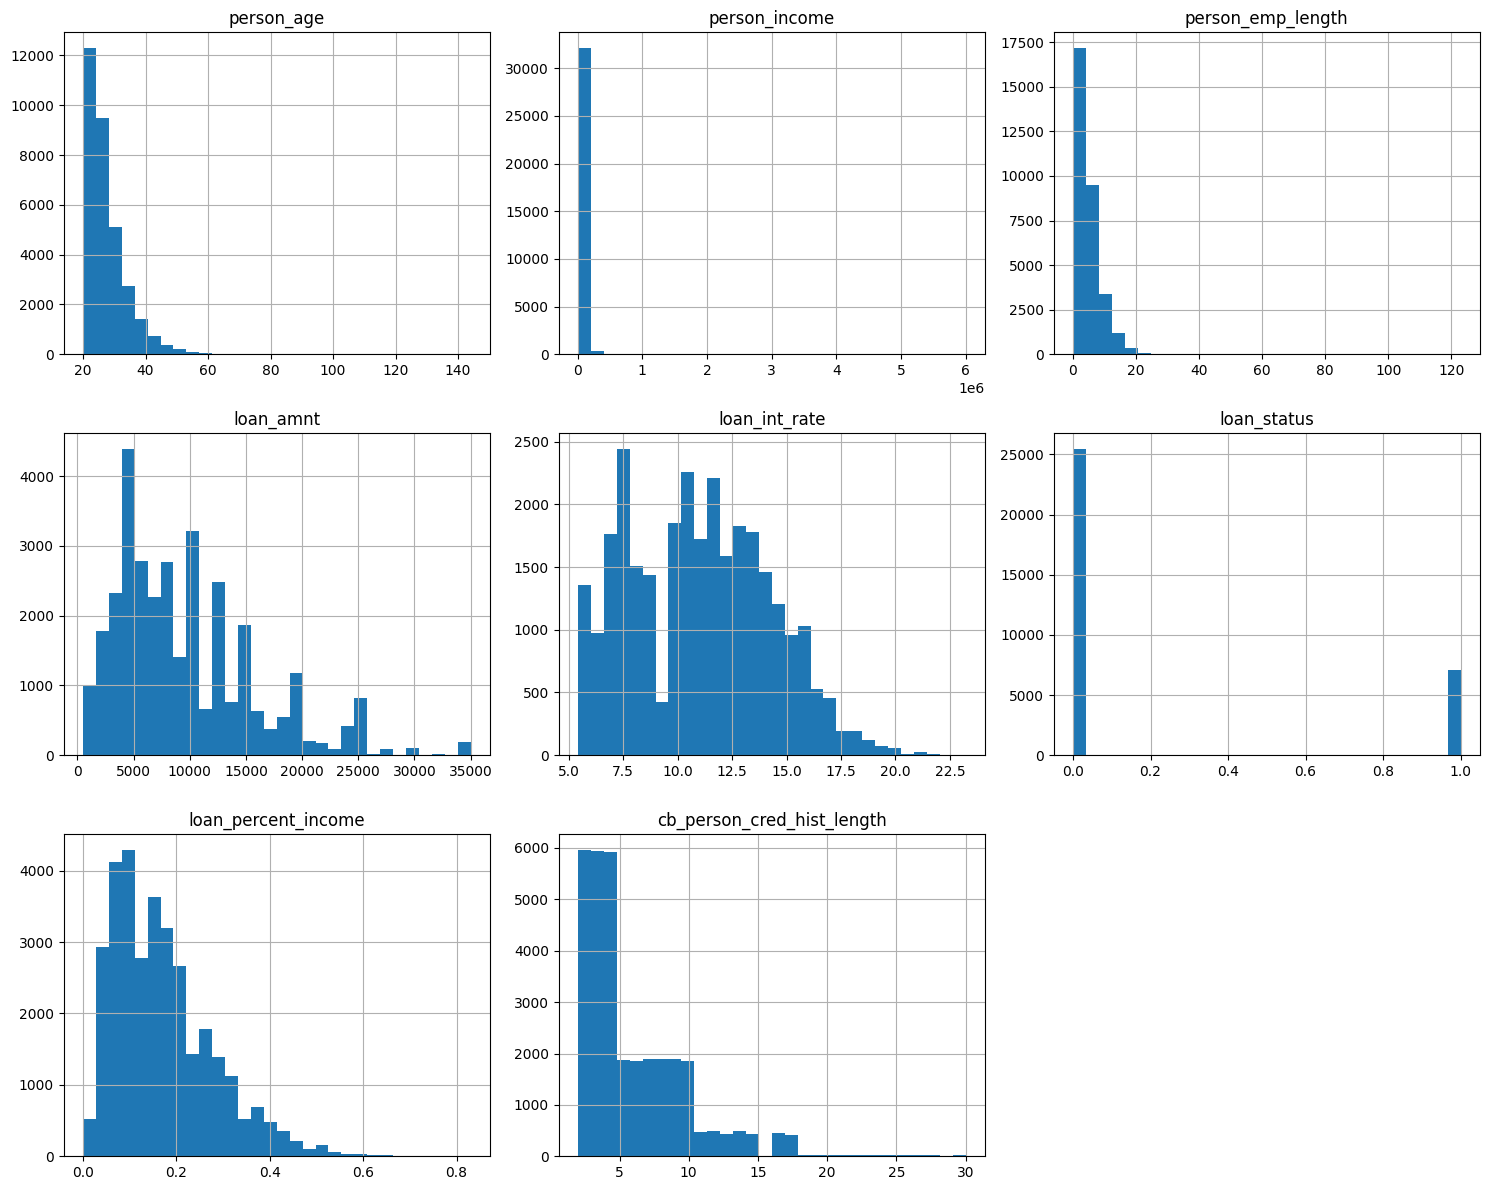

In [72]:
df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

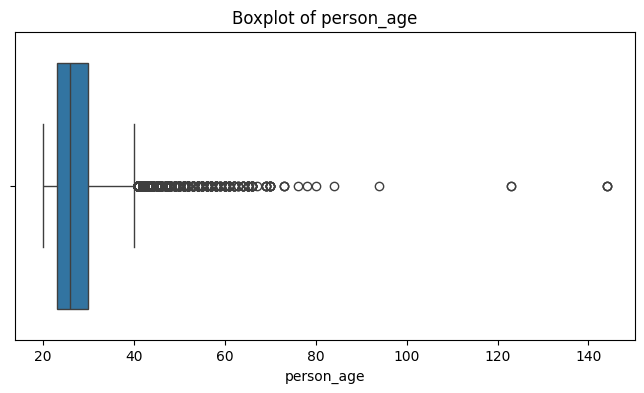

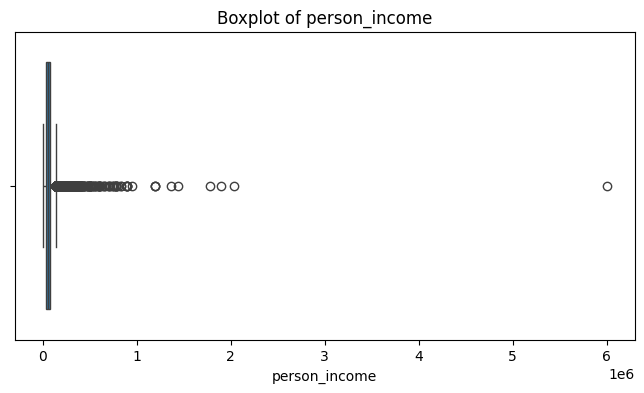

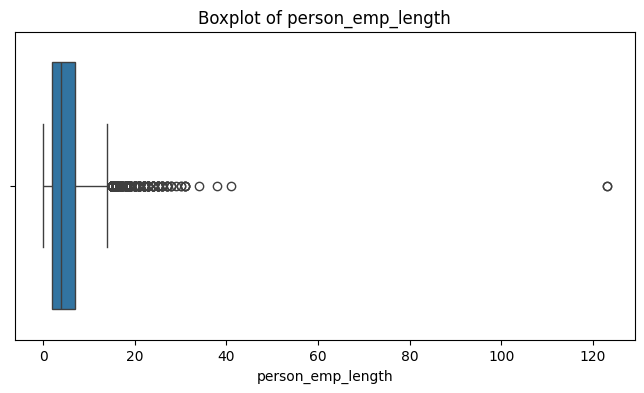

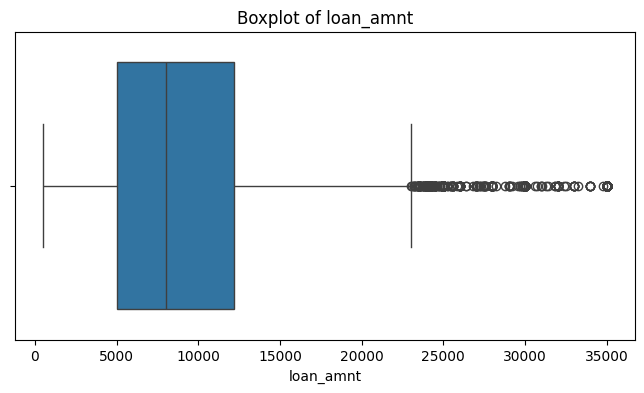

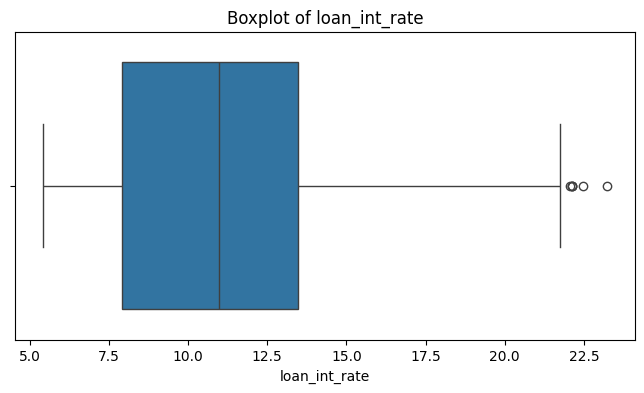

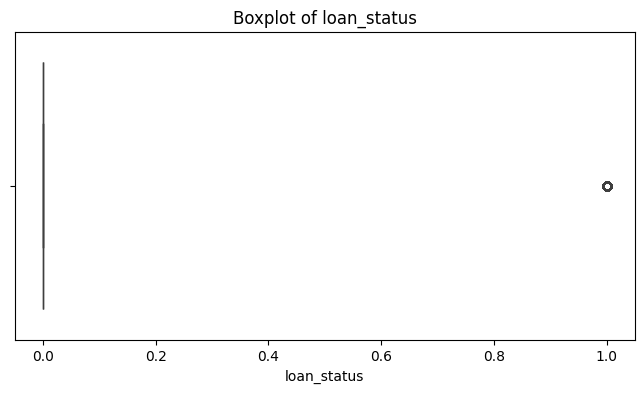

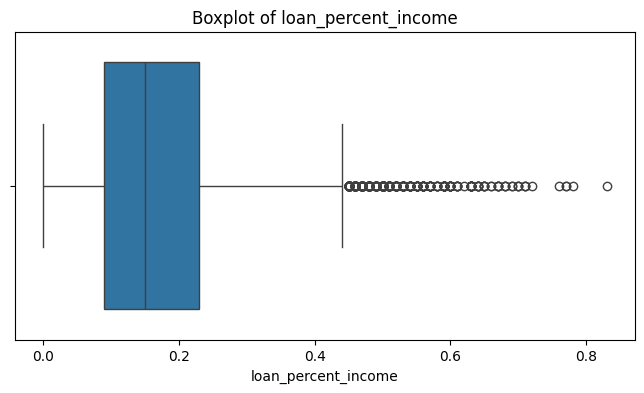

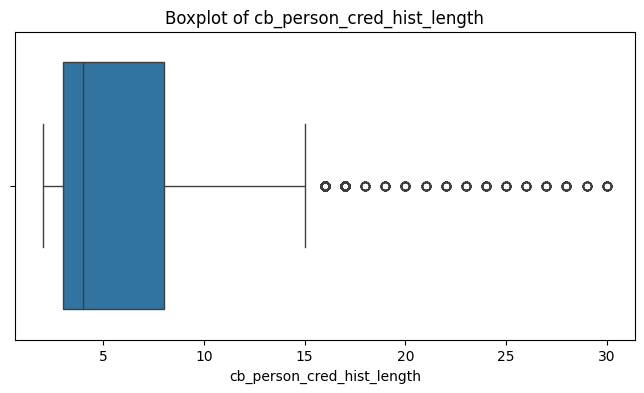

In [73]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

**Check Outliers**

In [74]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

person_age: 1494 outliers
person_income: 1484 outliers
person_emp_length: 853 outliers
loan_amnt: 1689 outliers
loan_int_rate: 6 outliers
loan_status: 7108 outliers
loan_percent_income: 651 outliers
cb_person_cred_hist_length: 1142 outliers


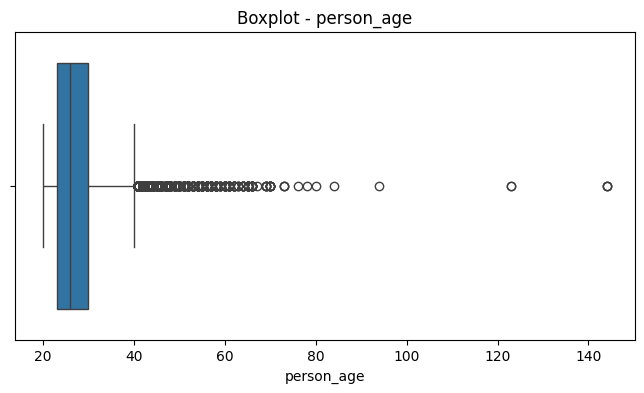

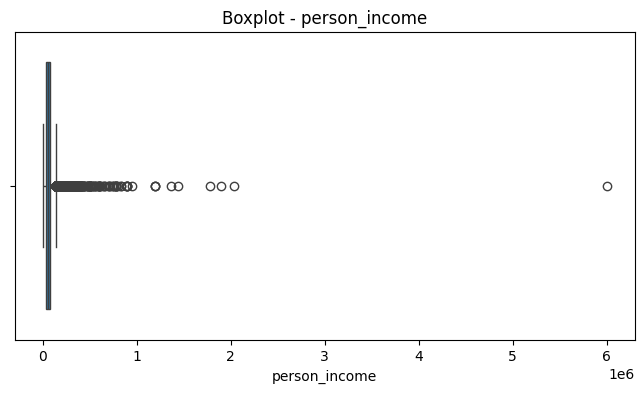

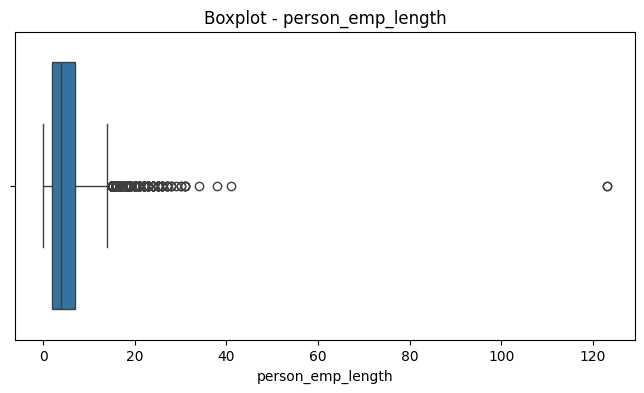

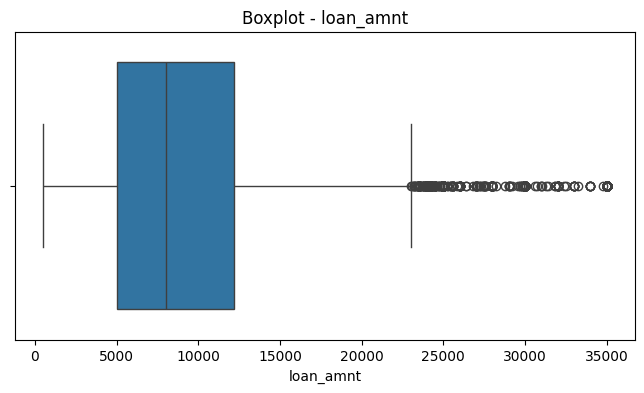

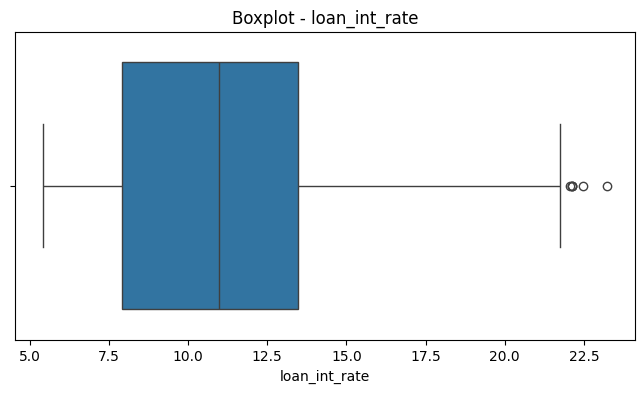

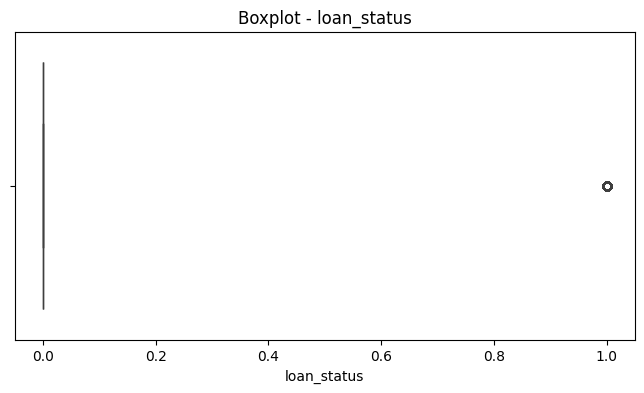

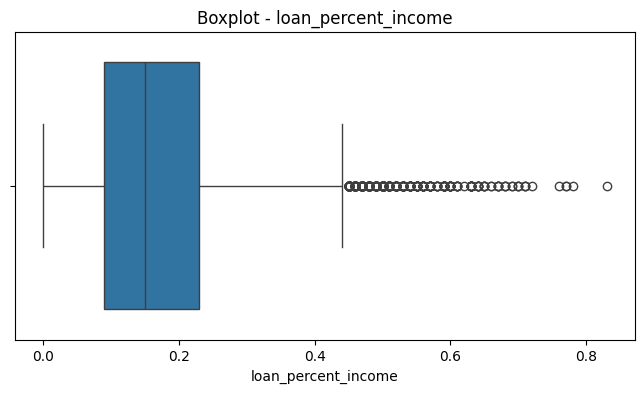

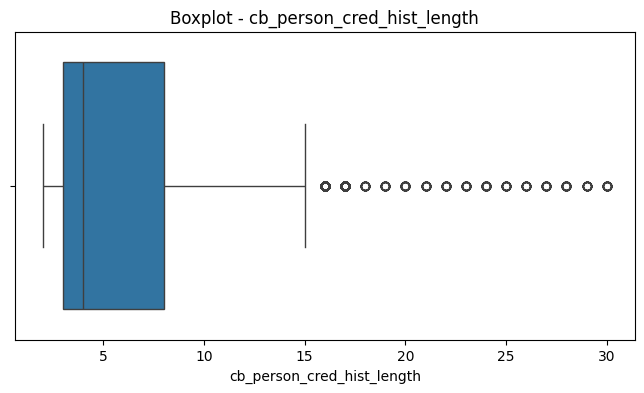

In [104]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)

    plt.show()

**Correlation Analysis**

In [75]:
correlation = df[numerical_cols].corr()

correlation

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


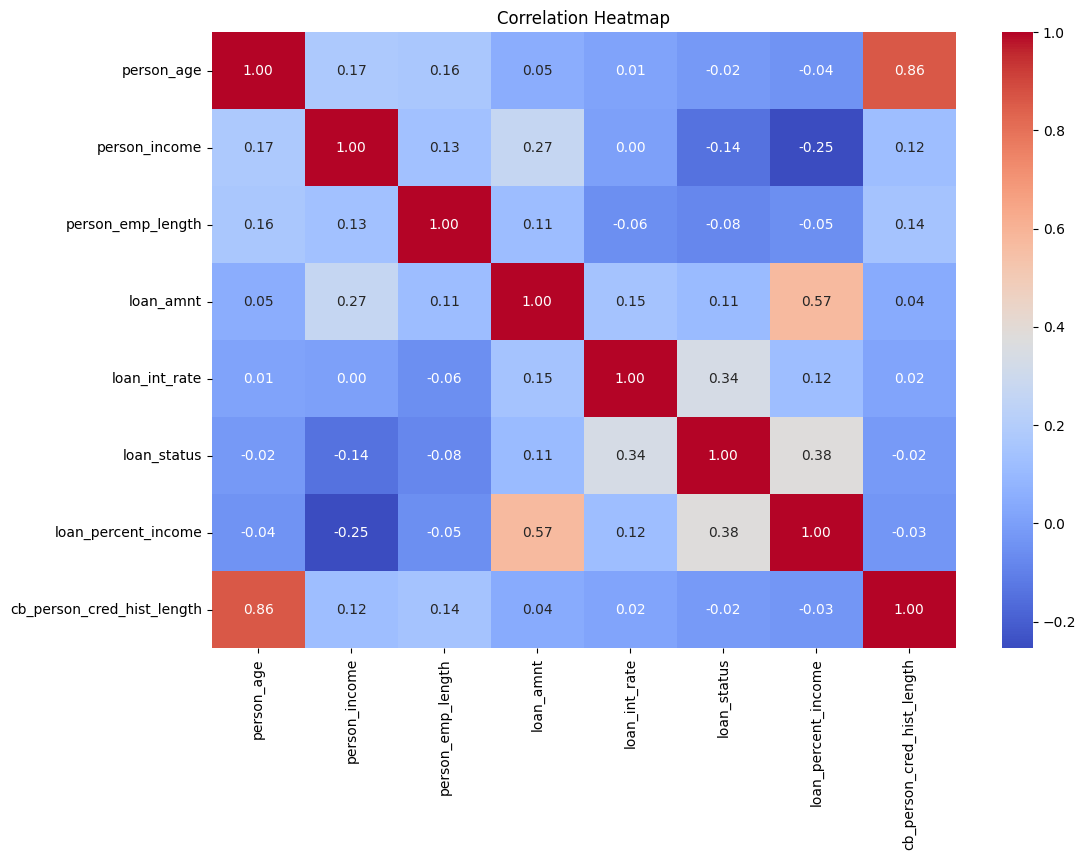

In [76]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()


Risk Rate by Different Features

In [77]:
df.groupby('loan_grade')['loan_status'].apply(
    lambda x: (x == 0).mean()
)

,loan_status
loan_grade,
A,0.900436
B,0.837240
C,0.792660
D,0.409542
E,0.355809
F,0.294606
G,0.015625


In [78]:
risk_by_home = df.groupby(
    'person_home_ownership'
)['loan_status'].apply(
    lambda x: (x == 0).mean() * 100
)

risk_by_home.sort_values(ascending=False)

,loan_status
person_home_ownership,
OWN,92.530960
MORTGAGE,87.429337
OTHER,69.158879
RENT,68.430013


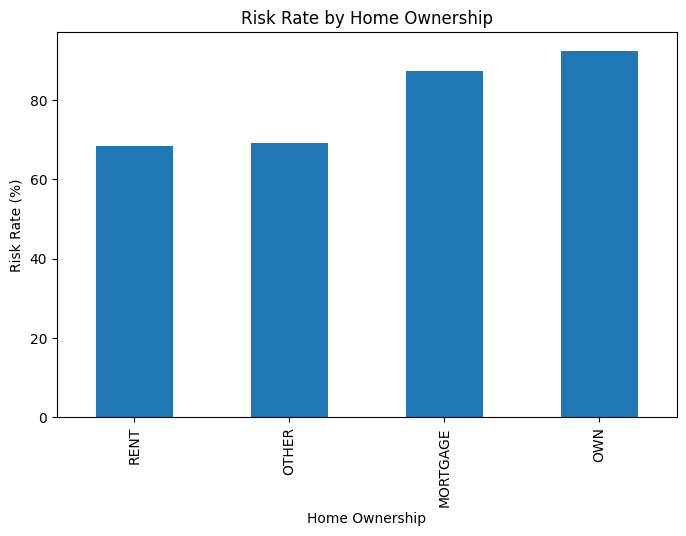

In [79]:
risk_by_home.sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Risk Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Risk Rate (%)")

plt.show()

In [80]:
risk_by_intent = df.groupby(
    'loan_intent'
)['loan_status'].apply(
    lambda x: (x == 0).mean() * 100
)

risk_by_intent.sort_values(ascending=False)

,loan_status
loan_intent,
VENTURE,85.189718
EDUCATION,82.783202
PERSONAL,80.112298
HOMEIMPROVEMENT,73.897365
MEDICAL,73.299292
DEBTCONSOLIDATION,71.412126


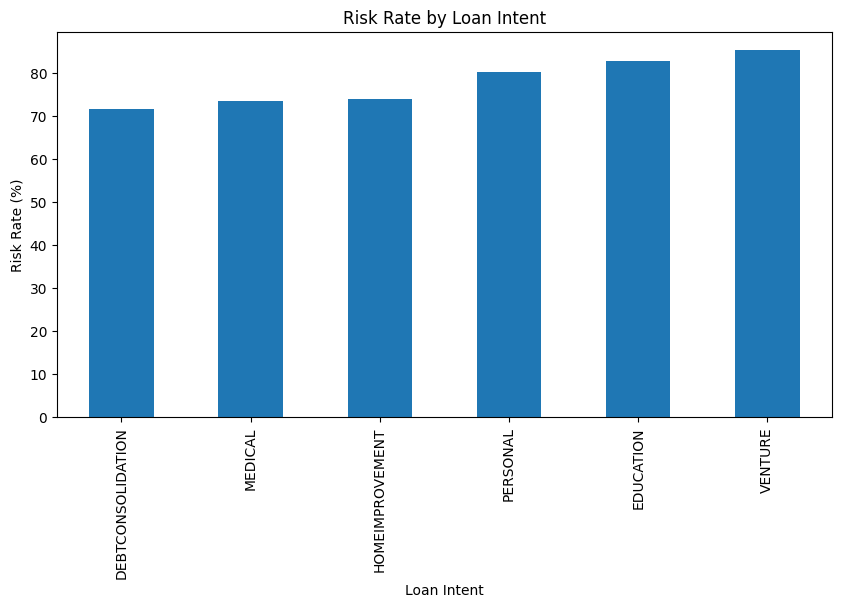

In [81]:
risk_by_intent.sort_values().plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Risk Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Risk Rate (%)")

plt.show()

In [82]:
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<=25', '26-35', '36-45', '46-55', '56+']
)

df.groupby('age_group', observed=True)['loan_status'].apply(
    lambda x: (x == 0).mean() * 100
)

,loan_status
age_group,
<=25,76.973684
26-35,79.321369
36-45,79.282161
46-55,78.167641
56+,76.119403


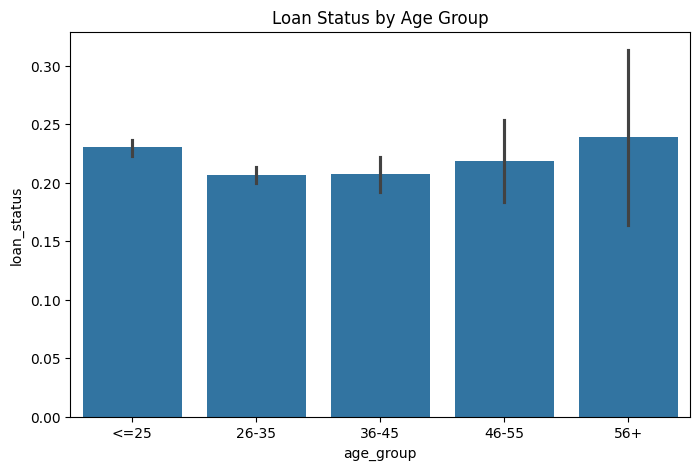

In [83]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='age_group',
    y='loan_status'
)

plt.title("Loan Status by Age Group")

plt.show()

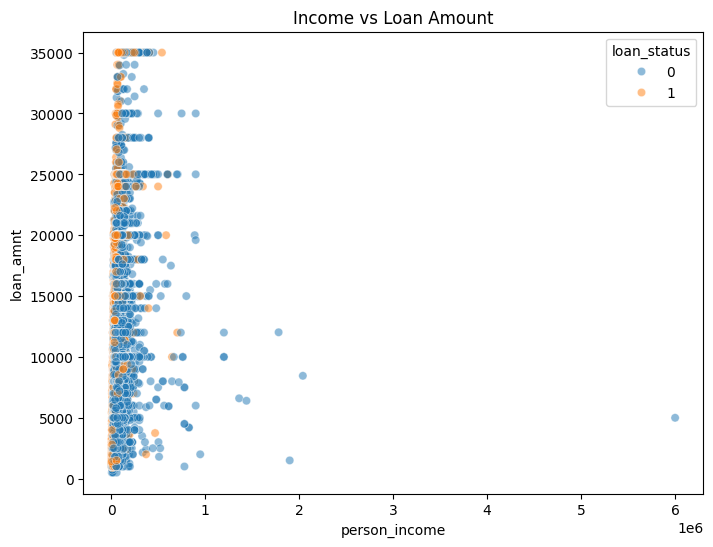

In [84]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='person_income',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5
)

plt.title("Income vs Loan Amount")

plt.show()

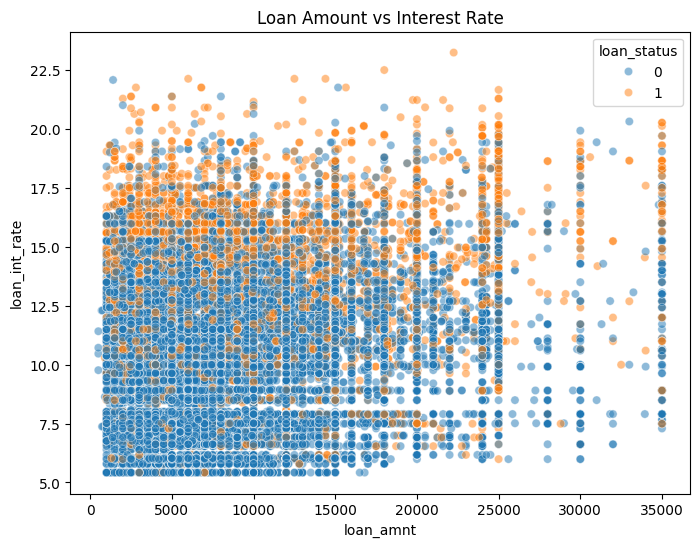

In [85]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='loan_amnt',
    y='loan_int_rate',
    hue='loan_status',
    alpha=0.5
)

plt.title("Loan Amount vs Interest Rate")

plt.show()

In [86]:
pd.crosstab(
    df['cb_person_default_on_file'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,0,1
cb_person_default_on_file,,
N,81.606797,18.393203
Y,62.193211,37.806789


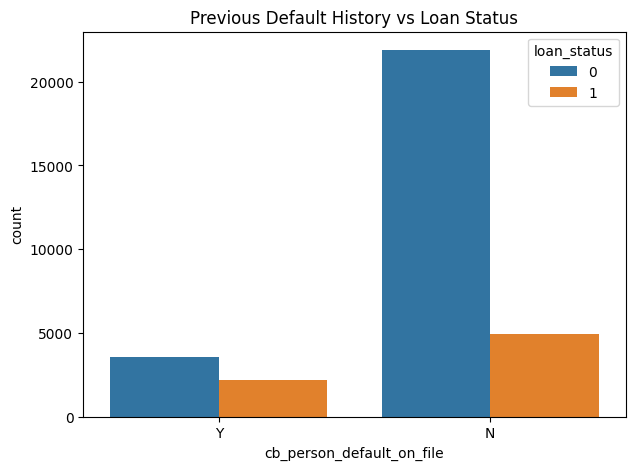

In [87]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='cb_person_default_on_file',
    hue='loan_status'
)

plt.title("Previous Default History vs Loan Status")

plt.show()

**Check Invalid Values**

In [88]:
df['person_age'].describe()

,person_age
count,32581.000000
mean,27.734600
std,6.348078
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


In [89]:
df[df['person_age'] < 18]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group


In [90]:
df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3,NaN
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2,NaN
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3,NaN
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4,NaN
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25,NaN


In [91]:
df[df['person_income'] <= 0]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group


In [92]:
df[df['person_emp_length'] < 0]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group


In [93]:
df[df['loan_amnt'] <= 0]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group


In [94]:
df[df['loan_int_rate'] <= 0]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group


Class ImBalance

In [95]:
class_counts = df['loan_status'].value_counts()

print(class_counts)

print("\nClass Percentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
0    25473
1     7108
Name: count, dtype: int64

Class Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Cross-tabulation

In [96]:
pd.crosstab(
    df['loan_grade'],
    df['loan_status']
)

loan_status,0,1
loan_grade,,
A,9704,1073
B,8750,1701
C,5119,1339
D,1485,2141
E,343,621
F,71,170
G,1,63


In [97]:
pd.crosstab(
    df['loan_grade'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,0,1
loan_grade,,
A,90.043611,9.956389
B,83.724046,16.275954
C,79.266027,20.733973
D,40.954220,59.045780
E,35.580913,64.419087
F,29.460581,70.539419
G,1.562500,98.437500


Multicollinearity Check

In [98]:
corr_matrix = df[numerical_cols].corr()

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1, len(corr_matrix.columns)):

        if abs(corr_matrix.iloc[i, j]) > 0.7:

            high_corr.append(
                (
                    corr_matrix.index[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                )
            )

high_corr

[('person_age', 'cb_person_cred_hist_length', np.float64(0.8591331885974023))]

Pair Plot

In [99]:
pair_cols = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'person_age',
    'loan_status'
]

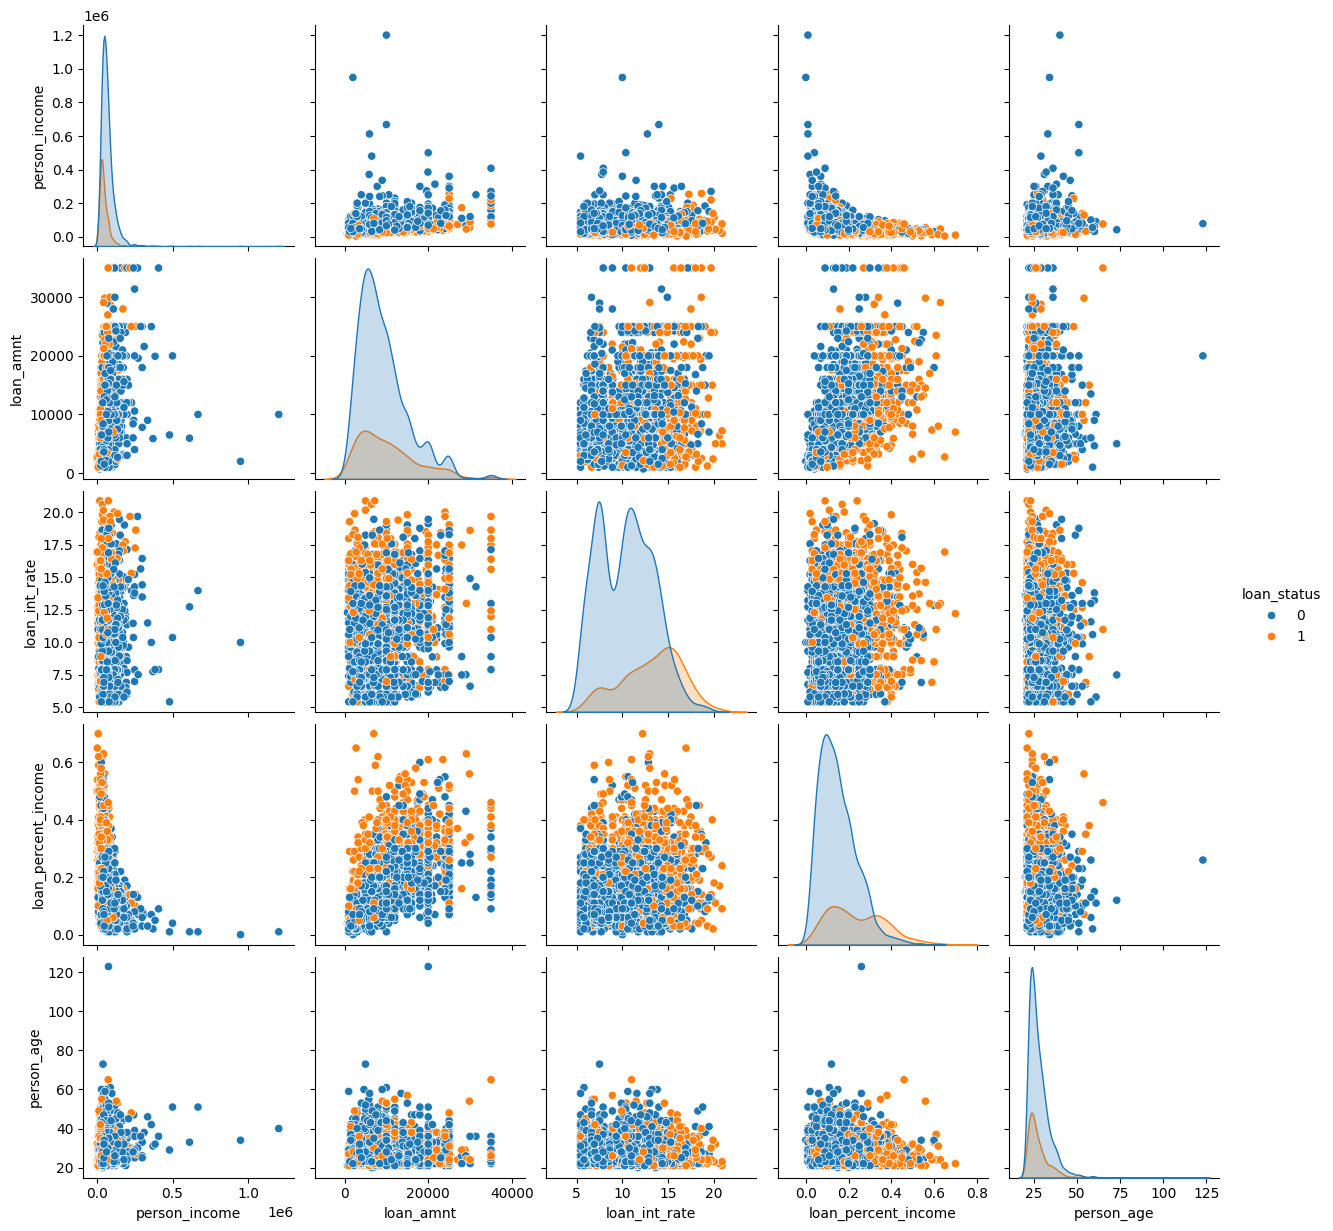

In [100]:
sample_df = df.sample(
    n=3000,
    random_state=42
)

sns.pairplot(
    sample_df[pair_cols],
    hue='loan_status',
    diag_kind='kde'
)

plt.show()

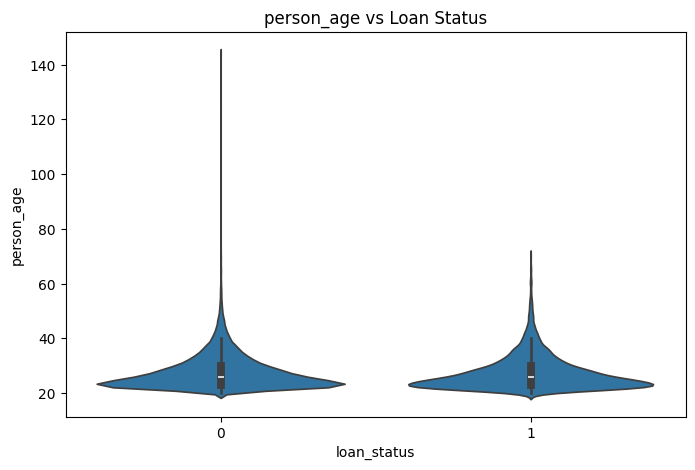

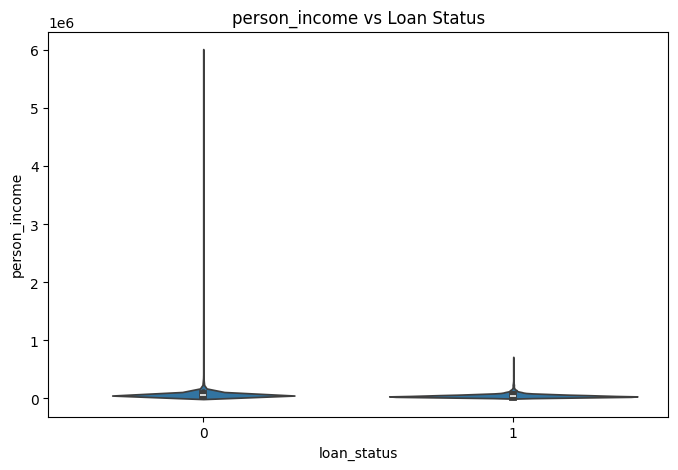

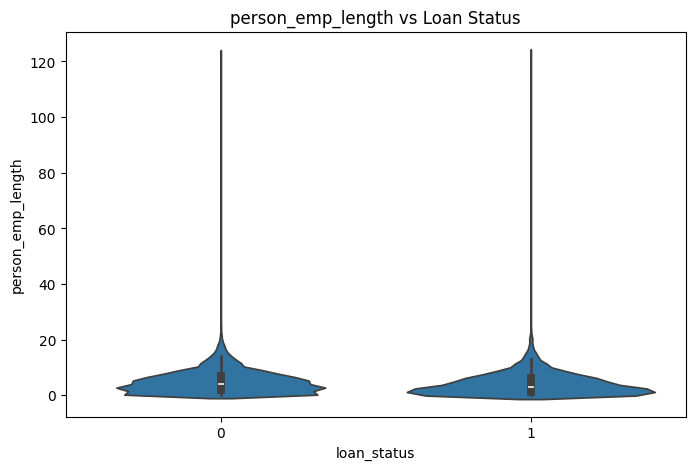

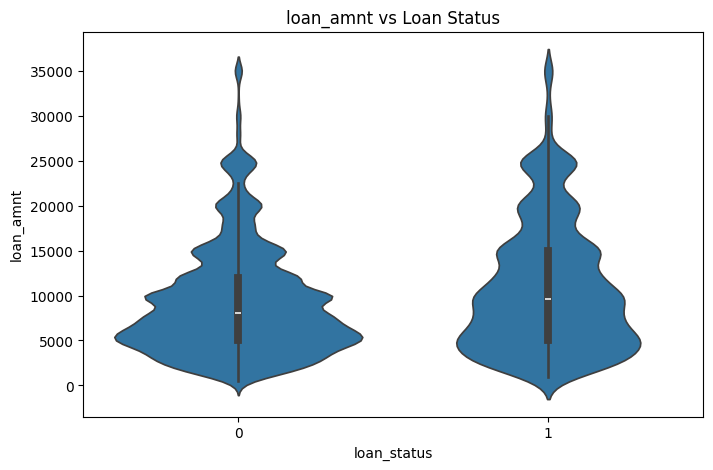

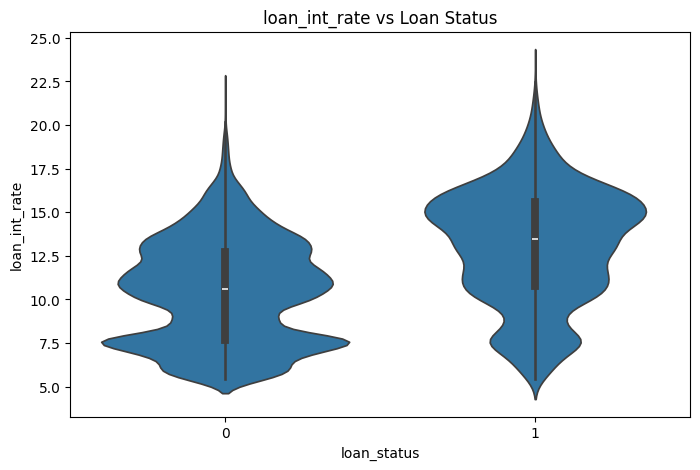

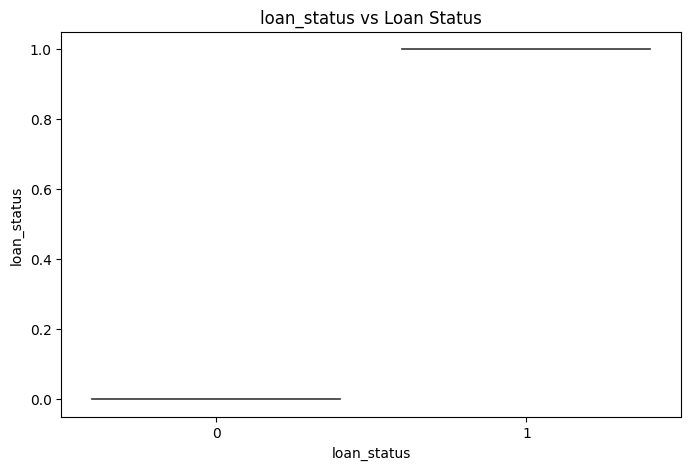

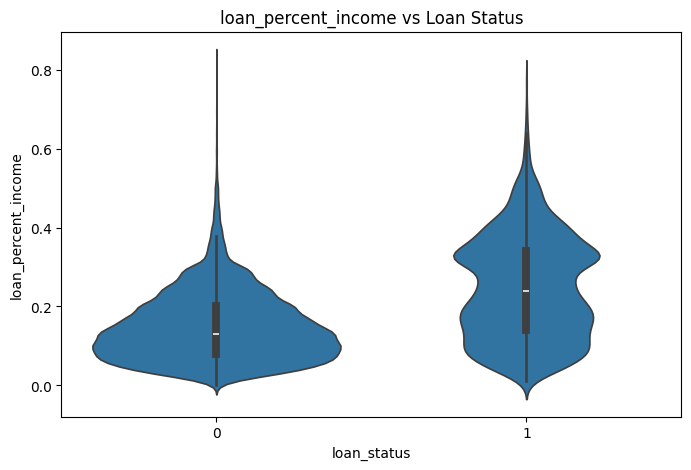

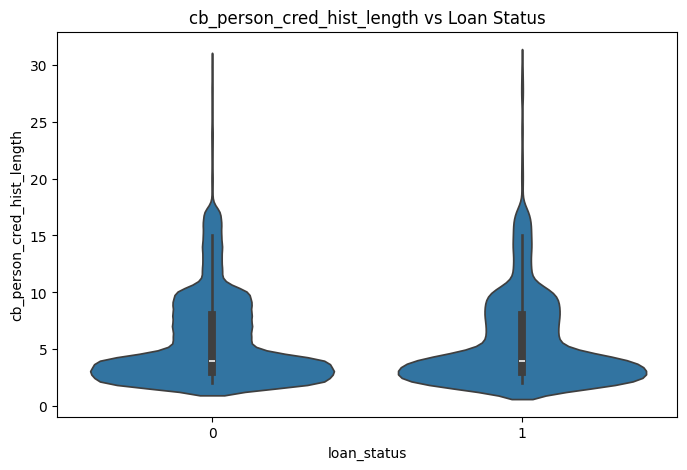

In [101]:
for col in numerical_cols:

    plt.figure(figsize=(8, 5))

    sns.violinplot(
        data=df,
        x='loan_status',
        y=col
    )

    plt.title(f"{col} vs Loan Status")

    plt.show()

**EDA Summary**

In [102]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df['loan_status'].value_counts())

print("\nTarget Percentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

print("\nNumerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Dataset Shape: (32581, 13)

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
age_group                        5
dtype: int64

Duplicate Rows:
165

Target Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Target Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Numerical Columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# **Data Preprocessing**

In [105]:
df_clean = df.copy()

Removing duplicate rows

In [106]:
df_clean.duplicated().sum()

np.int64(165)

In [107]:
df_clean = df_clean.drop_duplicates()

In [108]:
df_clean.duplicated().sum()

np.int64(0)

Checking missing values

In [109]:
df_clean.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [110]:
df_clean.isnull().mean() * 100

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.736303
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.547754
loan_status,0.000000
loan_percent_income,0.000000


In [113]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy='median')

In [114]:
categorical_imputer = SimpleImputer(strategy='most_frequent')

Handle Invalid Values

In [112]:
print("Age < 18:")
print((df['person_age'] < 18).sum())

print("Income <= 0:")
print((df['person_income'] <= 0).sum())

print("Employment length < 0:")
print((df['person_emp_length'] < 0).sum())

print("Loan amount <= 0:")
print((df['loan_amnt'] <= 0).sum())

print("Interest rate <= 0:")
print((df['loan_int_rate'] <= 0).sum())

print("Loan % income <= 0:")
print((df['loan_percent_income'] <= 0).sum())

Age < 18:
0
Income <= 0:
0
Employment length < 0:
0
Loan amount <= 0:
0
Interest rate <= 0:
0
Loan % income <= 0:
9


# ***Train-Test Split***

In [115]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [116]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 12)
y shape: (32581,)


In [117]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

loan_status
0    25473
1     7108
Name: count, dtype: int64

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [119]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26064, 12)
X_test : (6517, 12)
y_train: (26064,)
y_test : (6517,)


In [120]:
print("Training Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

Training Target Distribution:
loan_status
0    78.184469
1    21.815531
Name: proportion, dtype: float64


In [121]:
numerical_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

numerical_cols

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [122]:
categorical_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

categorical_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [123]:
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# ***Numerical And Categorical Preprocessing***

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [125]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [126]:
from sklearn.preprocessing import OneHotEncoder

In [127]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [128]:
from sklearn.compose import ColumnTransformer

In [129]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [130]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['person_age', 'person_income',
                                  'person_emp_length', 'loan_amnt',
                                  'loan_int_rate', 'loan_percent_income',
                                  'cb_person_cred_hist_length']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['person_home_ownership', 'loan_intent',
                                  'loan_grade', 'cb_person_default_on_file'])])

In [131]:
X_train_processed = preprocessor.fit_transform(X_train)

In [132]:
X_test_processed = preprocessor.transform(X_test)

In [133]:
print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("Original X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (26064, 12)
Processed X_train: (26064, 26)
Original X_test: (6517, 12)
Processed X_test: (6517, 26)


In [134]:
X_train_processed[:5]

array([[-0.42716311,  2.75966614, -0.18763034,  1.02145474, -1.28839641,
        -0.93795613, -0.44281673,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-1.05935771, -0.75404017,  0.05538284, -1.28166412,  0.37932712,
        -0.84432792, -0.44281673,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-0.42716311, -0.20471702,  1.27044871,  1.02145474,  0.49310942,
         1.21549281, -0.93851434,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
       

# **Logistic Regression Pipeline**

In [135]:
from sklearn.linear_model import LogisticRegression

In [136]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [137]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [138]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [139]:
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

# **Random Forest Pipeline**

In [140]:
from sklearn.ensemble import RandomForestClassifier

In [141]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [142]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [160]:
y_pred_rf = rf_pipeline.predict(X_test)

In [161]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# **Gradient Boosting Pipeline**

In [144]:
from sklearn.ensemble import GradientBoostingClassifier

In [145]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [146]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=300,
                                            random_state=42))])

In [147]:
y_pred_gb = gb_pipeline.predict(X_test)

In [148]:
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

# **XGBoost Pipeline**

In [150]:
!pip install xgboost

In [151]:
from xgboost import XGBClassifier

In [152]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [153]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [154]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [155]:
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# **Evaluate the Models**

In [156]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [157]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
    print("PR-AUC   :", average_precision_score(y_true, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [158]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)


Logistic Regression
Accuracy : 0.8671167715206384
Precision: 0.7667946257197696
Recall   : 0.5618846694796061
F1 Score : 0.648538961038961
ROC-AUC  : 0.8693385451388458
PR-AUC   : 0.7289996715163343

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517

Confusion Matrix:
[[4852  243]
 [ 623  799]]


In [162]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest
Accuracy : 0.9337118305969004
Precision: 0.9732313575525813
Recall   : 0.7158931082981715
F1 Score : 0.8249594813614263
ROC-AUC  : 0.9319895267001512
PR-AUC   : 0.8840165344298093

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517

Confusion Matrix:
[[5067   28]
 [ 404 1018]]


In [163]:
evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_prob_gb
)


Gradient Boosting
Accuracy : 0.9298757096823692
Precision: 0.9582146248812915
Recall   : 0.709563994374121
F1 Score : 0.8153535353535354
ROC-AUC  : 0.9298144674531303
PR-AUC   : 0.8785147973896066

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5095
           1       0.96      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

Confusion Matrix:
[[5051   44]
 [ 413 1009]]


In [164]:
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


XGBoost
Accuracy : 0.9341721651066441
Precision: 0.9751196172248804
Recall   : 0.7165963431786216
F1 Score : 0.8261045804620997
ROC-AUC  : 0.9494964175738329
PR-AUC   : 0.9051264480017139

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.98      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517

Confusion Matrix:
[[5069   26]
 [ 403 1019]]


# **Compare All 4 Models**

In [165]:
results = []

models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Gradient Boosting": (y_pred_gb, y_prob_gb),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

for name, (y_pred, y_prob) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339,0.729000
1,Random Forest,0.933712,0.973231,0.715893,0.824959,0.931990,0.884017
2,Gradient Boosting,0.929876,0.958215,0.709564,0.815354,0.929814,0.878515
3,XGBoost,0.934172,0.975120,0.716596,0.826105,0.949496,0.905126


In [166]:
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
3,XGBoost,0.934172,0.975120,0.716596,0.826105,0.949496,0.905126
1,Random Forest,0.933712,0.973231,0.715893,0.824959,0.931990,0.884017
2,Gradient Boosting,0.929876,0.958215,0.709564,0.815354,0.929814,0.878515
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339,0.729000


In [167]:
results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
3,XGBoost,0.934172,0.975120,0.716596,0.826105,0.949496,0.905126
1,Random Forest,0.933712,0.973231,0.715893,0.824959,0.931990,0.884017
2,Gradient Boosting,0.929876,0.958215,0.709564,0.815354,0.929814,0.878515
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339,0.729000


In [168]:
results_df.sort_values(
    by='PR-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
3,XGBoost,0.934172,0.975120,0.716596,0.826105,0.949496,0.905126
1,Random Forest,0.933712,0.973231,0.715893,0.824959,0.931990,0.884017
2,Gradient Boosting,0.929876,0.958215,0.709564,0.815354,0.929814,0.878515
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339,0.729000


Confusion Matrices

In [169]:
from sklearn.metrics import ConfusionMatrixDisplay

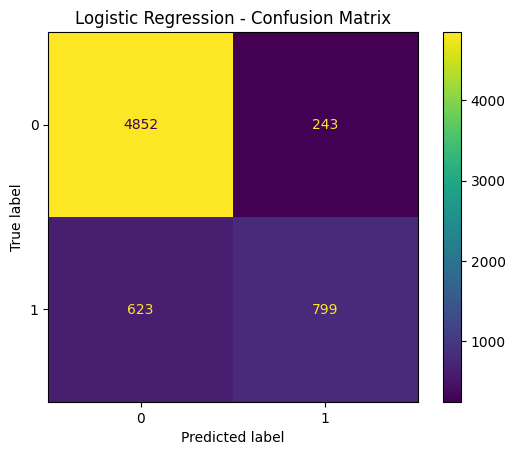

In [170]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

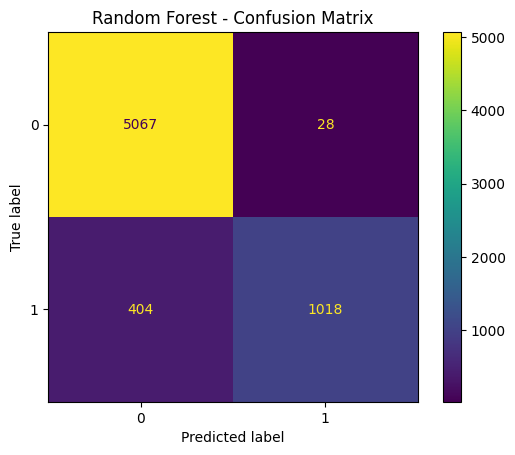

In [171]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

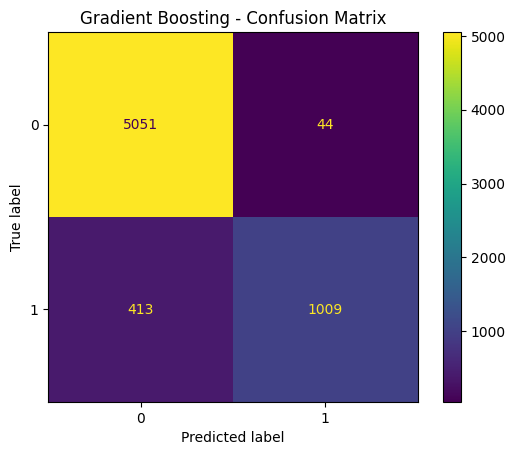

In [173]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

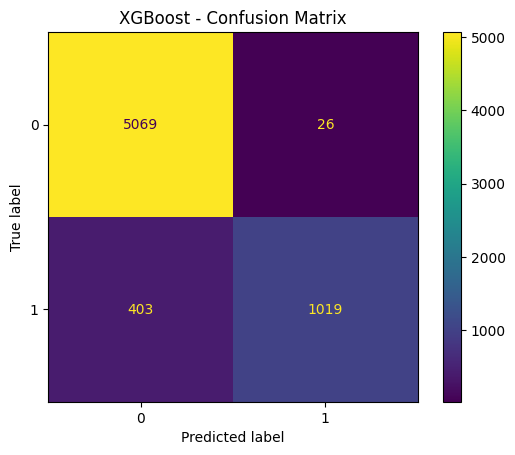

In [172]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

ROC-AUC Curve Comparison

In [174]:
from sklearn.metrics import RocCurveDisplay

<Figure size 800x600 with 0 Axes>

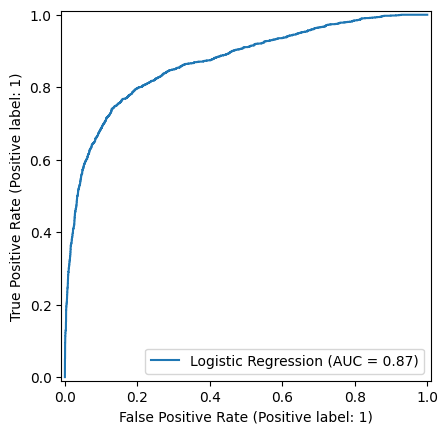

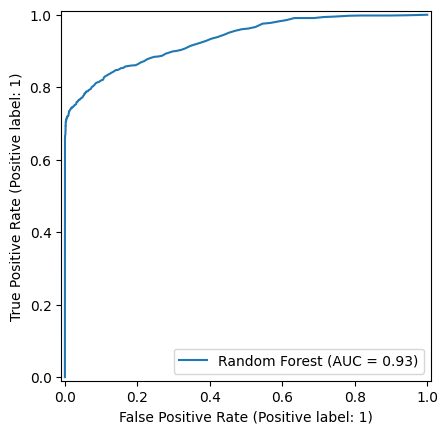

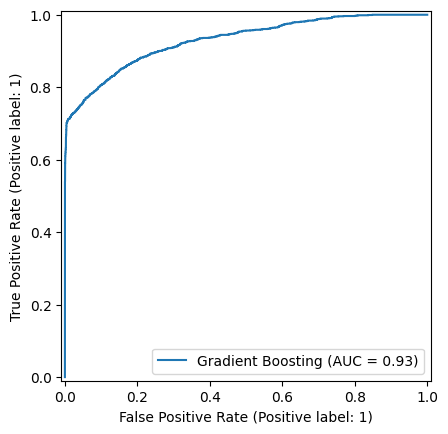

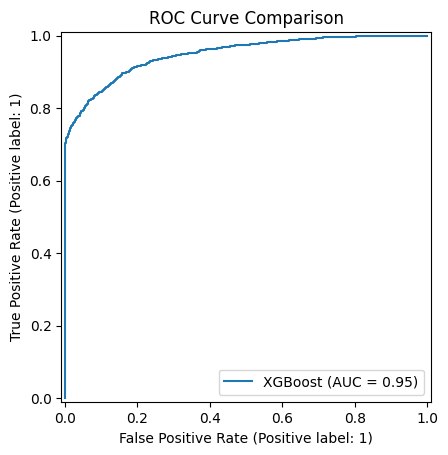

In [175]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.show()

Precision-Recall Curve

In [176]:
from sklearn.metrics import PrecisionRecallDisplay

<Figure size 800x600 with 0 Axes>

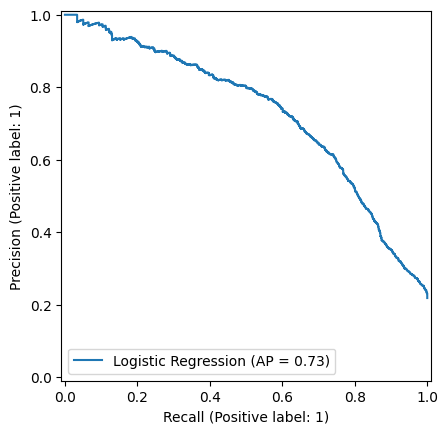

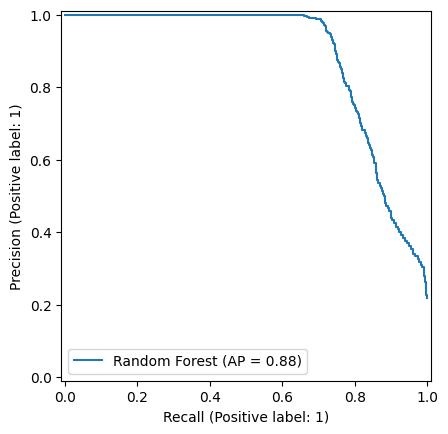

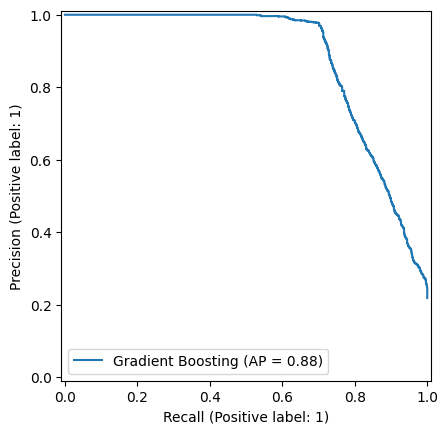

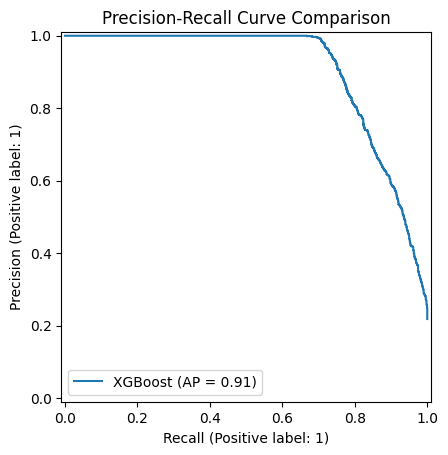

In [177]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

# **Probability Calibration**

In [178]:
from sklearn.calibration import calibration_curve

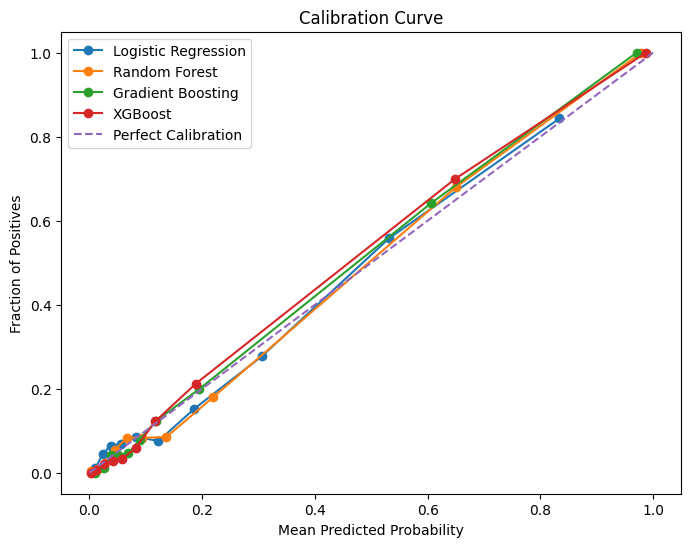

In [179]:
models_prob = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb,
    "XGBoost": y_prob_xgb
}

plt.figure(figsize=(8, 6))

for name, y_prob in models_prob.items():

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        y_prob,
        n_bins=10,
        strategy='quantile'
    )

    plt.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker='o',
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# **Classification Threshold Analysis**

In [180]:
import numpy as np

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.519623,0.931083,0.667003
1,0.15,0.656217,0.868495,0.747579
2,0.20,0.761378,0.823488,0.791216
3,0.25,0.836582,0.784810,0.809869
4,0.30,0.894389,0.762307,0.823083
5,0.35,0.924545,0.749648,0.827961
6,0.40,0.945848,0.736990,0.828458
7,0.45,0.963619,0.726442,0.828388
8,0.50,0.975120,0.716596,0.826105
9,0.55,0.980639,0.712377,0.825255


Plot Precision, Recall and F1

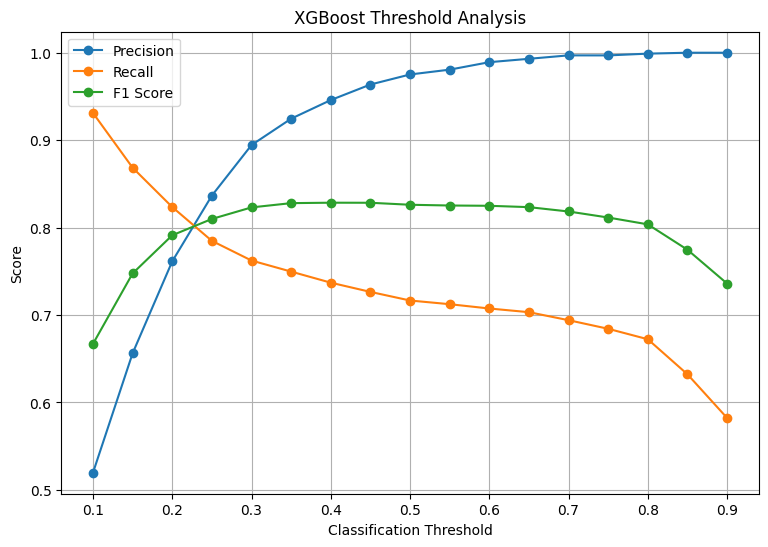

In [181]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [182]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold_row

,6
Threshold,0.400000
Precision,0.945848
Recall,0.736990
F1 Score,0.828458


# **Hyperparameter Tuning**

In [183]:
from sklearn.model_selection import GridSearchCV

In [184]:
xgb_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [185]:
param_grid = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [186]:
xgb_grid = GridSearchCV(
    estimator=xgb_tuning_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [187]:
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['person_age',
                                                                          'person_income',
                                                                          'person_emp_length',
                                                                          'loan_amnt',
                                                                          'loan_int_rate',
                                                                          'loan_percent_income',
                                                                          'cb_person_cred_hist_length']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impu...
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__learning_rate': [0.03, 0.05, 0.1],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [200, 300, 400],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [189]:
print("Best Parameters:")
print(xgb_grid.best_params_)

Best Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 400, 'classifier__subsample': 1.0}


In [188]:
print("Best CV ROC-AUC:")
print(xgb_grid.best_score_)

Best CV ROC-AUC:
0.9483074455348447


In [190]:
best_xgb = xgb_grid.best_estimator_

Evaluate Tuned XGBoost and Normal XGB

In [191]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

In [192]:
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [193]:
evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_xgb_tuned,
    y_prob_xgb_tuned
)


Tuned XGBoost
Accuracy : 0.9363203928187817
Precision: 0.9675023212627669
Recall   : 0.7327707454289732
F1 Score : 0.8339335734293718
ROC-AUC  : 0.9549571502907486
PR-AUC   : 0.9136767073986484

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.73      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.86      0.90      6517
weighted avg       0.94      0.94      0.93      6517

Confusion Matrix:
[[5060   35]
 [ 380 1042]]


In [194]:
xgb_comparison = pd.DataFrame({
    "Model": [
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_xgb_tuned)
    ]
})

xgb_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Original XGBoost,0.934172,0.975120,0.716596,0.826105,0.949496,0.905126
1,Tuned XGBoost,0.936320,0.967502,0.732771,0.833934,0.954957,0.913677


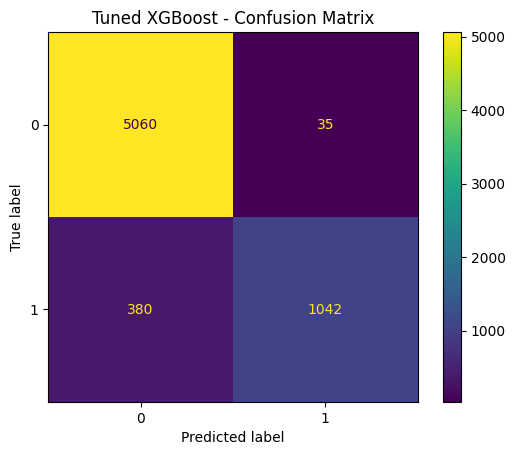

In [195]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_tuned
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

# **SHAP Explainability**

In [196]:
import shap

In [197]:
fitted_preprocessor = best_xgb.named_steps['preprocessor']

In [198]:
xgb_model = best_xgb.named_steps['classifier']

In [199]:
X_test_transformed = fitted_preprocessor.transform(X_test)

In [200]:
feature_names = fitted_preprocessor.get_feature_names_out()

In [201]:
len(feature_names)

26

In [202]:
X_test_transformed.shape

(6517, 26)

In [203]:
explainer = shap.TreeExplainer(xgb_model)

In [204]:
X_shap = X_test_transformed[:2000]

shap_values = explainer.shap_values(X_shap)

In [205]:
X_shap = X_test_transformed[:2000]

shap_values = explainer.shap_values(X_shap)

In [206]:
feature_names

array(['num__person_age', 'num__person_income', 'num__person_emp_length',
       'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income',
       'num__cb_person_cred_hist_length',
       'cat__person_home_ownership_MORTGAGE',
       'cat__person_home_ownership_OTHER',
       'cat__person_home_ownership_OWN',
       'cat__person_home_ownership_RENT',
       'cat__loan_intent_DEBTCONSOLIDATION', 'cat__loan_intent_EDUCATION',
       'cat__loan_intent_HOMEIMPROVEMENT', 'cat__loan_intent_MEDICAL',
       'cat__loan_intent_PERSONAL', 'cat__loan_intent_VENTURE',
       'cat__loan_grade_A', 'cat__loan_grade_B', 'cat__loan_grade_C',
       'cat__loan_grade_D', 'cat__loan_grade_E', 'cat__loan_grade_F',
       'cat__loan_grade_G', 'cat__cb_person_default_on_file_N',
       'cat__cb_person_default_on_file_Y'], dtype=object)

In [ ]:
shap.dependence_plot(
    'num__loan_percent_income',
    shap_values,
    X_shap,
    feature_names=feature_names
)

# **Final Model**

In [207]:
import joblib

In [208]:
joblib.dump(
    best_xgb,
    'credit_risk_xgb_pipeline.pkl'
)

['credit_risk_xgb_pipeline.pkl']

In [209]:
import os

print(
    "File exists:",
    os.path.exists('credit_risk_xgb_pipeline.pkl')
)

File exists: True


In [210]:
loaded_model = joblib.load(
    'credit_risk_xgb_pipeline.pkl'
)

In [211]:
test_predictions = loaded_model.predict(X_test)

print(test_predictions[:10])

[0 0 0 0 0 0 0 0 0 1]


In [212]:
test_probabilities = loaded_model.predict_proba(X_test)[:, 1]

print(test_probabilities[:10])

[0.03348851 0.01856808 0.01188258 0.03589319 0.00096221 0.19804603
 0.12042767 0.03607485 0.00129733 0.93225765]


In [213]:
from google.colab import files

files.download("credit_risk_xgb_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>